In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
'''!unzip "/content/drive/MyDrive/Mis estudios /BBS/Woxsen/dementia.zip" -d /content/dataset'''

'!unzip "/content/drive/MyDrive/Mis estudios /BBS/Woxsen/dementia.zip" -d /content/dataset'

In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2 # Import a pre-trained model
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import numpy as np
import os
import datetime

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lukechugh/best-alzheimer-mri-dataset-99-accuracy")

print("Path to dataset files:", path)

#Checking the content of the main folder
print("Dataset path:", path)
print("\nContent of the main folder:")
print(os.listdir(path))

print(os.listdir(os.path.join(path, "Combined Dataset"))) #Seeing what's inside of the "combined dataset"

Using Colab cache for faster access to the 'best-alzheimer-mri-dataset-99-accuracy' dataset.
Path to dataset files: /kaggle/input/best-alzheimer-mri-dataset-99-accuracy
Dataset path: /kaggle/input/best-alzheimer-mri-dataset-99-accuracy

Content of the main folder:
['Combined Dataset']
['test', 'train']


In [5]:

# --- Section 2: Data Loading and Preprocessing ---

# Paths to train and test folders from the Kaggle dataset
dataset_path = os.path.join(path, "Combined Dataset")
train_dir = os.path.join(dataset_path, "train")
test_dir = os.path.join(dataset_path, "test")

# Define image dimensions and batch size
# Adjusted to a standard size for pre-trained models like MobileNetV2
img_height, img_width = 224, 224
batch_size = 32
epochs = 25

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

validation_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

# Test data (no augmentation, only rescaling)
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

class_names = list(train_generator.class_indices.keys())
print("Class labels:", class_names)
num_classes = len(class_names)


Found 8192 images belonging to 4 classes.
Found 2048 images belonging to 4 classes.
Found 1279 images belonging to 4 classes.
Class labels: ['Mild Impairment', 'Moderate Impairment', 'No Impairment', 'Very Mild Impairment']


In [6]:

# --- Section 3: Build the Model with Transfer Learning ---

# Load the pre-trained MobileNetV2 model, excluding the top layers
base_model = MobileNetV2(
    input_shape=(img_height, img_width, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze the base model to prevent its weights from being updated during training
base_model.trainable = False

# Create a new model on top of the base model
model = Sequential([
    base_model,
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:

# --- Section 4: Compile and Train the Model ---

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint

# Compile the model with a lower learning rate for fine-tuning
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# Define checkpoint directory (replace with your Drive path)
checkpoint_path = "/content/drive/MyDrive/Mis estudios/BBS/Woxsen/NewDataset_checkpoint_best_model.h5"

# Callback to save the best model based on validation accuracy
checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

# Train the model with checkpoint callback
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=validation_generator,
    callbacks=[checkpoint_callback]
)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 62720)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    32,113,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,373,188 (131.12 MB)

 Trainable params: 32,115,204 (122.51 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

...

256/256 ━━━━━━━━━━━━━━━━━━━━ 140s 548ms/step - accuracy: 0.6774 - loss: 0.7288 - val_accuracy: 0.6592 - val_loss: 0.6795
Epoch 4/25
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.6927 - loss: 0.6990
Epoch 4: val_accuracy improved from 0.65918 to 0.68652, saving model to /content/drive/MyDrive/Mis estudios/BBS/Woxsen/NewDataset_checkpoint_best_model.h5


256/256 ━━━━━━━━━━━━━━━━━━━━ 141s 551ms/step - accuracy: 0.6927 - loss: 0.6990 - val_accuracy: 0.6865 - val_loss: 0.6697
Epoch 5/25
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.7155 - loss: 0.6552
Epoch 5: val_accuracy improved from 0.68652 to 0.69385, saving model to /content/drive/MyDrive/Mis estudios/BBS/Woxsen/NewDataset_checkpoint_best_model.h5


256/256 ━━━━━━━━━━━━━━━━━━━━ 139s 545ms/step - accuracy: 0.7155 - loss: 0.6552 - val_accuracy: 0.6938 - val_loss: 0.6369
Epoch 6/25
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.7147 - loss: 0.6468
Epoch 6: val_accuracy did not improve from 0.69385
256/256 ━━━━━━━━━━━━━━━━━━━━ 134s 524ms/step - accuracy: 0.7147 - loss: 0.6467 - val_accuracy: 0.6719 - val_loss: 0.6554
Epoch 7/25
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.7266 - loss: 0.6295
Epoch 7: val_accuracy did not improve from 0.69385
256/256 ━━━━━━━━━━━━━━━━━━━━ 125s 489ms/step - accuracy: 0.7267 - loss: 0.6295 - val_accuracy: 0.6812 - val_loss: 0.6323
Epoch 8/25
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step - accuracy: 0.7390 - loss: 0.6084
Epoch 8: val_accuracy did not improve from 0.69385
256/256 ━━━━━━━━━━━━━━━━━━━━ 124s 486ms/step - accuracy: 0.7390 - loss: 0.6083 - val_accuracy: 0.6616 - val_loss: 0.6415
Epoch 9/25
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.7447 - loss: 0.5780
Epoch 9: va

256/256 ━━━━━━━━━━━━━━━━━━━━ 134s 526ms/step - accuracy: 0.7447 - loss: 0.5780 - val_accuracy: 0.7061 - val_loss: 0.6018
Epoch 10/25
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.7404 - loss: 0.5859
Epoch 10: val_accuracy did not improve from 0.70605
256/256 ━━━━━━━━━━━━━━━━━━━━ 137s 535ms/step - accuracy: 0.7404 - loss: 0.5859 - val_accuracy: 0.6992 - val_loss: 0.6200
Epoch 11/25
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 0.7489 - loss: 0.5785
Epoch 11: val_accuracy did not improve from 0.70605
256/256 ━━━━━━━━━━━━━━━━━━━━ 127s 495ms/step - accuracy: 0.7489 - loss: 0.5785 - val_accuracy: 0.6738 - val_loss: 0.6581
Epoch 12/25
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step - accuracy: 0.7481 - loss: 0.5843
Epoch 12: val_accuracy did not improve from 0.70605
256/256 ━━━━━━━━━━━━━━━━━━━━ 124s 483ms/step - accuracy: 0.7481 - loss: 0.5843 - val_accuracy: 0.6812 - val_loss: 0.6624
Epoch 13/25
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 0.7428 - loss: 0.5820
Epoc

256/256 ━━━━━━━━━━━━━━━━━━━━ 136s 531ms/step - accuracy: 0.7591 - loss: 0.5412 - val_accuracy: 0.7075 - val_loss: 0.6292
Epoch 18/25
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.7671 - loss: 0.5367
Epoch 18: val_accuracy did not improve from 0.70752
256/256 ━━━━━━━━━━━━━━━━━━━━ 142s 531ms/step - accuracy: 0.7671 - loss: 0.5367 - val_accuracy: 0.6738 - val_loss: 0.7024
Epoch 19/25
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.7693 - loss: 0.5396
Epoch 19: val_accuracy did not improve from 0.70752
256/256 ━━━━━━━━━━━━━━━━━━━━ 126s 492ms/step - accuracy: 0.7692 - loss: 0.5396 - val_accuracy: 0.6919 - val_loss: 0.6258
Epoch 20/25
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.7674 - loss: 0.5494
Epoch 20: val_accuracy did not improve from 0.70752
256/256 ━━━━━━━━━━━━━━━━━━━━ 124s 486ms/step - accuracy: 0.7674 - loss: 0.5494 - val_accuracy: 0.6875 - val_loss: 0.6388
Epoch 21/25
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 0.7609 - loss: 0.5480
Epoc

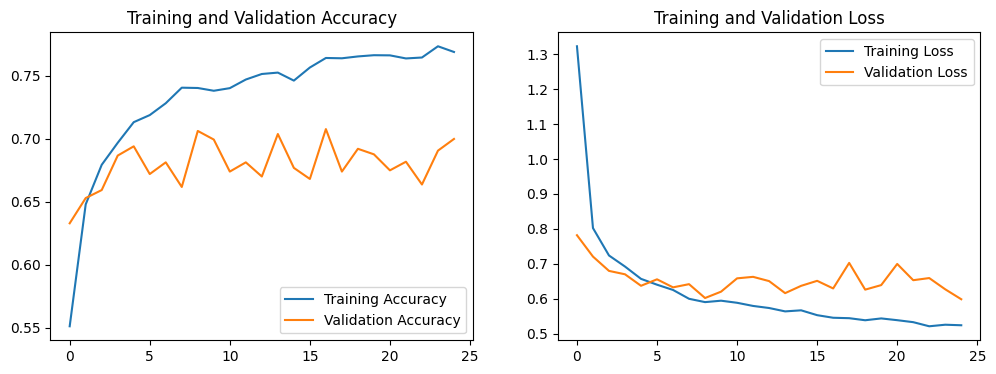

In [8]:

# --- Section 5: Visualize Training Results ---

# Plotting the results
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(epochs)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()


In [9]:

# --- Section 6: Save the Trained Model ---

timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
model_filename = f'alzheimers_transfer_learning_model_{timestamp}.h5'
model.save(model_filename)
print(f"\nModel saved successfully as: {model_filename}")

# Note: You can use the previous prediction script with this new model file.



Model saved successfully as: alzheimers_transfer_learning_model_20250909-102023.h5


In [10]:
# Disconnecting the notebook after everything has been executed
print("Trabajo completado. Desconectando runtime...")
from google.colab import runtime
runtime.unassign()

Trabajo completado. Desconectando runtime...
